In [14]:
import torch
import torchvision
import sys

print("="*50)
print("PYTORCH & GPU CHECK")
print("="*50)
print(f"PyTorch Version: {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print("="*50)

PYTORCH & GPU CHECK
PyTorch Version: 2.10.0+cu128
Torchvision Version: 0.25.0+cu128
GPU Available: True
GPU Device: Tesla T4
GPU Memory: 15.64 GB


In [15]:
from google.colab import drive
drive.mount('/content/drive')
print("✓ Google Drive mounted successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted successfully


In [16]:
import os
from pathlib import Path

In [17]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"jamalmasooddd","key":"99afd7f7c7eb34483cd81eda8bd4e521"}'}

In [18]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [19]:
!kaggle datasets list --max-results 5

usage: kaggle [-h] [-v] [-W]
              {competitions,c,datasets,d,kernels,k,models,m,files,f,config,auth}
              ...
kaggle: error: unrecognized arguments: --max-results 5


In [20]:
import os
from pathlib import Path

# Download dataset
!kaggle datasets download -d fatimahirshad/faceforensics-c32-frames-cropped-aligned --unzip -p /content/dataset

# Verify download
dataset_path = Path('/content/dataset')
print(f"Dataset path: {dataset_path}")
print(f"Contents: {list(dataset_path.iterdir())}")

Dataset URL: https://www.kaggle.com/datasets/fatimahirshad/faceforensics-c32-frames-cropped-aligned
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 210M/210M [00:00<00:00, 243MB/s]

Dataset path: /content/dataset
Contents: [PosixPath('/content/dataset/Frames(Crop+Align).csv'), PosixPath('/content/dataset/Frames(cropped+aligned)'), PosixPath('/content/dataset/CSVs')]


In [21]:
from pathlib import Path
from collections import defaultdict

dataset_path = Path('/content/dataset')

# Count images per class
class_counts = defaultdict(int)
class_paths = {}

print("\n" + "="*50)
print("DATASET STRUCTURE")
print("="*50)

for class_folder in sorted(dataset_path.iterdir()):
    if class_folder.is_dir():
        class_name = class_folder.name

        # Count images
        images = list(class_folder.glob('*.png')) + list(class_folder.glob('*.jpg'))
        image_count = len(images)
        class_counts[class_name] = image_count
        class_paths[class_name] = class_folder

        print(f"{class_name:20s}: {image_count:5d} images")

total_images = sum(class_counts.values())
print("="*50)
print(f"TOTAL: {total_images:5d} images")
print("="*50 + "\n")



DATASET STRUCTURE
CSVs                :     0 images
Frames(cropped+aligned):     0 images
TOTAL:     0 images



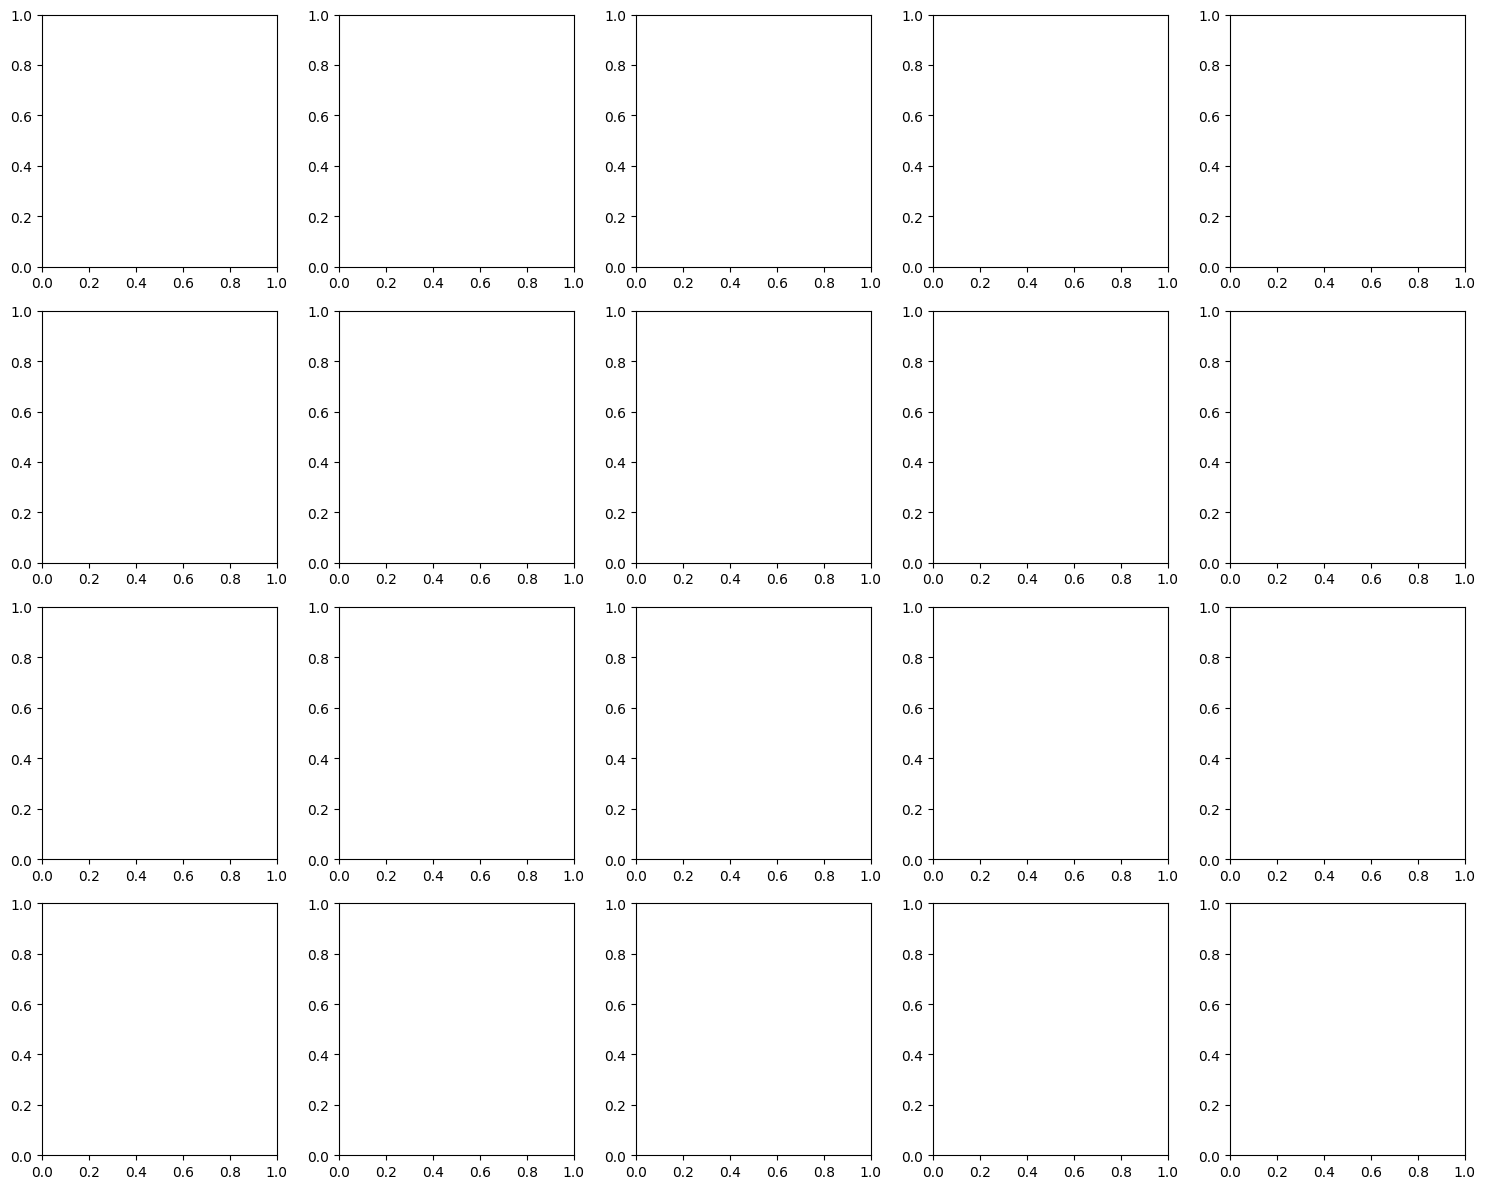

✓ Samples visualization saved!


In [22]:
import matplotlib.pyplot as plt
import random
from PIL import Image

# Show 20 random samples (3-4 per class)
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

all_images = []
for class_name, class_path in class_paths.items():
    images = list(class_path.glob('*.png')) + list(class_path.glob('*.jpg'))
    all_images.extend([(img, class_name) for img in images[:5]])  # 5 per class

random.shuffle(all_images)

for idx, (img_path, class_name) in enumerate(all_images[:20]):
    img = Image.open(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(class_name, fontsize=10)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FYP/dataset_samples.png', dpi=150)
plt.show()

print("✓ Samples visualization saved!")

In [27]:
!git clone https://github.com/MuhammadJamall/Deepfake_Detection.git /content/repo

print("✓ Repository cloned")

Cloning into '/content/repo'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 31 (delta 7), reused 24 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 10.01 KiB | 1.67 MiB/s, done.
Resolving deltas: 100% (7/7), done.
✓ Repository cloned


In [31]:
# CELL 9: Setup Python path and import dataset module
import sys
sys.path.append('/content/Deepfake_Detection')  # Add PARENT folder, not src/

from src.dataset import get_dataloaders, get_transforms
from src.utils import plot_sample_batch, check_gpu

print("✓ All imports successful!")

✓ All imports successful!


In [35]:
from pathlib import Path

dataset_path = Path('/content/dataset')

print("Full directory structure:")
for root, dirs, files in Path(dataset_path).walk():
    level = len(Path(root).relative_to(dataset_path).parts)
    indent = "  " * level
    print(f"{indent}📁 {Path(root).name}/")
    for file in files[:5]:  # Show first 5 files
        print(f"{indent}  📄 {file}")
    if len(files) > 5:
        print(f"{indent}  ... and {len(files) - 5} more files")

Full directory structure:
📁 dataset/
  📄 Frames(Crop+Align).csv
  📁 Frames(cropped+aligned)/
    📁 Original/
      📄 920_f0.jpg
      📄 140_f4.jpg
      📄 416_f0.jpg
      📄 550_f0.jpg
      📄 217_f0.jpg
      ... and 4988 more files
    📁 Deepfakes/
      📄 211_177_f3.jpg
      📄 406_391_f4.jpg
      📄 732_691_f1.jpg
      📄 131_518_f0.jpg
      📄 356_324_f0.jpg
      ... and 4965 more files
    📁 FaceSwap/
      📄 211_177_f3.jpg
      📄 406_391_f4.jpg
      📄 732_691_f1.jpg
      📄 131_518_f0.jpg
      📄 356_324_f0.jpg
      ... and 4989 more files
    📁 NeuralTextures/
      📄 211_177_f3.jpg
      📄 406_391_f4.jpg
      📄 732_691_f1.jpg
      📄 131_518_f0.jpg
      📄 356_324_f0.jpg
      ... and 4990 more files
    📁 Face2Face/
      📄 211_177_f3.jpg
      📄 406_391_f4.jpg
      📄 732_691_f1.jpg
      📄 131_518_f0.jpg
      📄 356_324_f0.jpg
      ... and 4995 more files
    📁 FaceShifter/
      📄 211_177_f3.jpg
      📄 406_391_f4.jpg
      📄 732_691_f1.jpg
      📄 131_518_f0.jpg
   

In [39]:
from pathlib import Path

frames_path = Path('/content/dataset/Frames(cropped+aligned)')

print("Contents of Frames(cropped+aligned):")
for item in sorted(frames_path.iterdir()):
    if item.is_dir():
        img_count = len(list(item.glob('*.png'))) + len(list(item.glob('*.jpg')))
        print(f"  📁 {item.name}/ → {img_count} images")
    else:
        print(f"  📄 {item.name}")

Contents of Frames(cropped+aligned):
  📁 Deepfakes/ → 4970 images
  📁 Face2Face/ → 5000 images
  📁 FaceShifter/ → 4992 images
  📁 FaceSwap/ → 4994 images
  📁 NeuralTextures/ → 4995 images
  📁 Original/ → 4993 images


In [40]:
print("\nCreating dataloaders...")

train_loader, val_loader, test_loader, class_to_idx = get_dataloaders(
    dataset_dir='/content/dataset/Frames(cropped+aligned)',  # ✅ Use this path
    batch_size=32,
    train_split=0.8,
    val_split=0.1,
    num_workers=2
)

print("✓ Dataloaders created successfully!")
print(f"Class mapping: {class_to_idx}")


Creating dataloaders...

✓ Dataset loaded from: /content/dataset/Frames(cropped+aligned)
✓ Total images: 29944
✓ Number of classes: 6
✓ Classes: ['Deepfakes', 'Face2Face', 'FaceShifter', 'FaceSwap', 'NeuralTextures', 'Original']

DATALOADER SPLIT
Training set: 23955 images (80%)
Validation set: 2994 images (10%)
Test set: 2995 images (10%)
Batch size: 32

✓ Dataloaders created successfully!
Class mapping: {'Deepfakes': 0, 'Face2Face': 1, 'FaceShifter': 2, 'FaceSwap': 3, 'NeuralTextures': 4, 'Original': 5}


In [41]:
images, labels = next(iter(train_loader))

print("\n" + "="*50)
print("BATCH VERIFICATION")
print("="*50)
print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Labels (sample): {labels[:8].tolist()}")
print(f"Image dtype: {images.dtype}")
print(f"Image value range: [{images.min().item():.3f}, {images.max().item():.3f}]")
print("="*50 + "\n")


BATCH VERIFICATION
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels (sample): [2, 1, 0, 4, 5, 1, 1, 3]
Image dtype: torch.float32
Image value range: [-2.118, 2.640]



In [42]:
plot_sample_batch(images, labels, class_to_idx,
                  save_path='/content/drive/MyDrive/FYP/batch_visualization.png')


✓ Batch visualization saved to /content/drive/MyDrive/FYP/batch_visualization.png


In [43]:
images, labels = next(iter(val_loader))

idx_to_class = {v: k for k, v in class_to_idx.items()}

print("\n" + "="*50)
print("DETAILED BATCH INSPECTION")
print("="*50)
print(f"Batch size: {len(images)}")
print(f"\nImage statistics:")
print(f"  Min value: {images.min().item():.4f}")
print(f"  Max value: {images.max().item():.4f}")
print(f"  Mean value: {images.mean().item():.4f}")
print(f"  Std dev: {images.std().item():.4f}")

print(f"\nLabel distribution in this batch:")
unique_labels, counts = torch.unique(labels, return_counts=True)
for label, count in zip(unique_labels, counts):
    class_name = idx_to_class[label.item()]
    print(f"  {class_name}: {count} samples")

print("="*50 + "\n")



DETAILED BATCH INSPECTION
Batch size: 32

Image statistics:
  Min value: -2.1179
  Max value: 2.6400
  Mean value: 0.0597
  Std dev: 1.0350

Label distribution in this batch:
  Deepfakes: 3 samples
  Face2Face: 11 samples
  FaceShifter: 6 samples
  FaceSwap: 4 samples
  NeuralTextures: 5 samples
  Original: 3 samples



In [44]:
train_batch_images, train_batch_labels = next(iter(train_loader))
print(f"✓ Train loader working - Batch shape: {train_batch_images.shape}")

# Test val loader
val_batch_images, val_batch_labels = next(iter(val_loader))
print(f"✓ Val loader working - Batch shape: {val_batch_images.shape}")

# Test test loader
test_batch_images, test_batch_labels = next(iter(test_loader))
print(f"✓ Test loader working - Batch shape: {test_batch_images.shape}")

print("\n✓ All dataloaders verified successfully!")


✓ Train loader working - Batch shape: torch.Size([32, 3, 224, 224])
✓ Val loader working - Batch shape: torch.Size([32, 3, 224, 224])
✓ Test loader working - Batch shape: torch.Size([32, 3, 224, 224])

✓ All dataloaders verified successfully!


In [45]:
import json

dataset_info = {
    "total_images": sum(class_counts.values()),
    "classes": list(class_to_idx.keys()),
    "class_distribution": dict(class_counts),
    "split": {
        "train": train_loader.dataset.__len__(),
        "val": val_loader.dataset.__len__(),
        "test": test_loader.dataset.__len__()
    },
    "batch_size": train_loader.batch_size,
    "image_size": 224
}

In [46]:
with open('/content/drive/MyDrive/FYP/dataset_info.json', 'w') as f:
    json.dump(dataset_info, f, indent=2)

print("✓ Dataset info saved to dataset_info.json")
print(json.dumps(dataset_info, indent=2))

✓ Dataset info saved to dataset_info.json
{
  "total_images": 0,
  "classes": [
    "Deepfakes",
    "Face2Face",
    "FaceShifter",
    "FaceSwap",
    "NeuralTextures",
    "Original"
  ],
  "class_distribution": {
    "CSVs": 0,
    "Frames(cropped+aligned)": 0
  },
  "split": {
    "train": 23955,
    "val": 2994,
    "test": 2995
  },
  "batch_size": 32,
  "image_size": 224
}
